In [ ]:
# Importing the packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# Importing the csv files
df_transactions = pd.read_csv('/content/df_transactions.csv')
df_kyc = pd.read_csv('/content/df_kyc.csv')
df_labels = pd.read_csv('/content/df_label.csv')

In [ ]:
# Merging the transactions and labesl.
df_merged = pd.merge(df_transactions, df_labels, on=["Customer_ID", "Month"], how="inner")

# Exclude salary transactions
df_merged = df_merged[df_merged["Transaction_Type"] != "Salary"]

# Aggregate Monthly Transaction Sums
df_monthly_sum = df_merged.groupby(["Customer_ID", "Month"]).agg(
    {"Transaction_Value": lambda x: x.abs().sum()}  # Sum of absolute transaction values
).reset_index()

# Step 2: Merge the aggregated monthly sums back to the original data otherwise I had lost the features.
df_merged = pd.merge(df_merged, df_monthly_sum, on=["Customer_ID", "Month"], suffixes=("", "_Monthly_Sum"))

df_merged = pd.merge(df_merged, df_kyc, on="Customer_ID", how="inner")

# Step 3: Split Trusted and Untrusted Data
# Trusted Data: Monthly sum exceeds 9000 OR SAR is 1 (reliable labels)
trusted_data = df_merged[
    (df_merged["Transaction_Value_Monthly_Sum"] > 9000)  # Threshold exceeded
    | (df_merged["SAR"] == 1)  # Labeled as suspicious
]

# Untrusted Data: Monthly sum ≤ 9000 and SAR is 0 (unreliable labels)
untrusted_data = df_merged[
    (df_merged["Transaction_Value_Monthly_Sum"] <= 9000)  # Below threshold
    & (df_merged["SAR"] == 0)  # Not flagged and unreliable
]


In [ ]:
# Remove the Transaction_Value_Monthly_Sum column
trusted_data = trusted_data.drop(columns=["Transaction_Value_Monthly_Sum"])
untrusted_data = untrusted_data.drop(columns=["Transaction_Value_Monthly_Sum"])

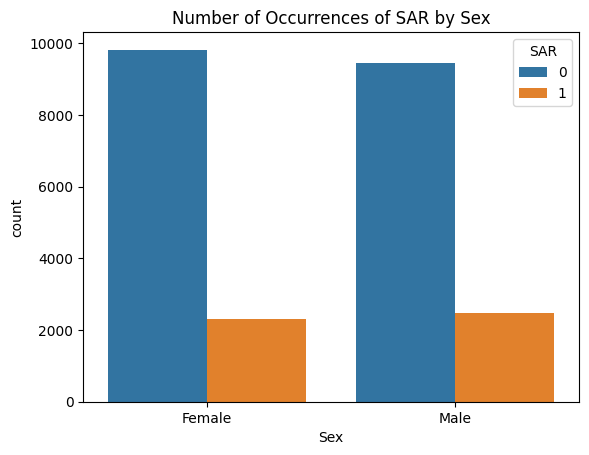

In [ ]:
sns.countplot(x='Sex', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Sex')
plt.show()

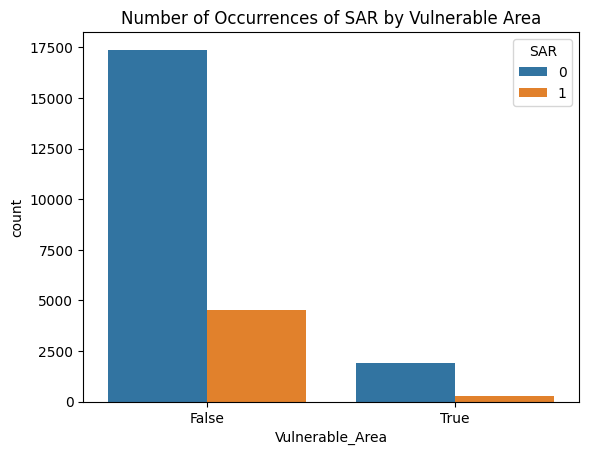

In [ ]:
sns.countplot(x='Vulnerable_Area', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Vulnerable Area')
plt.show()

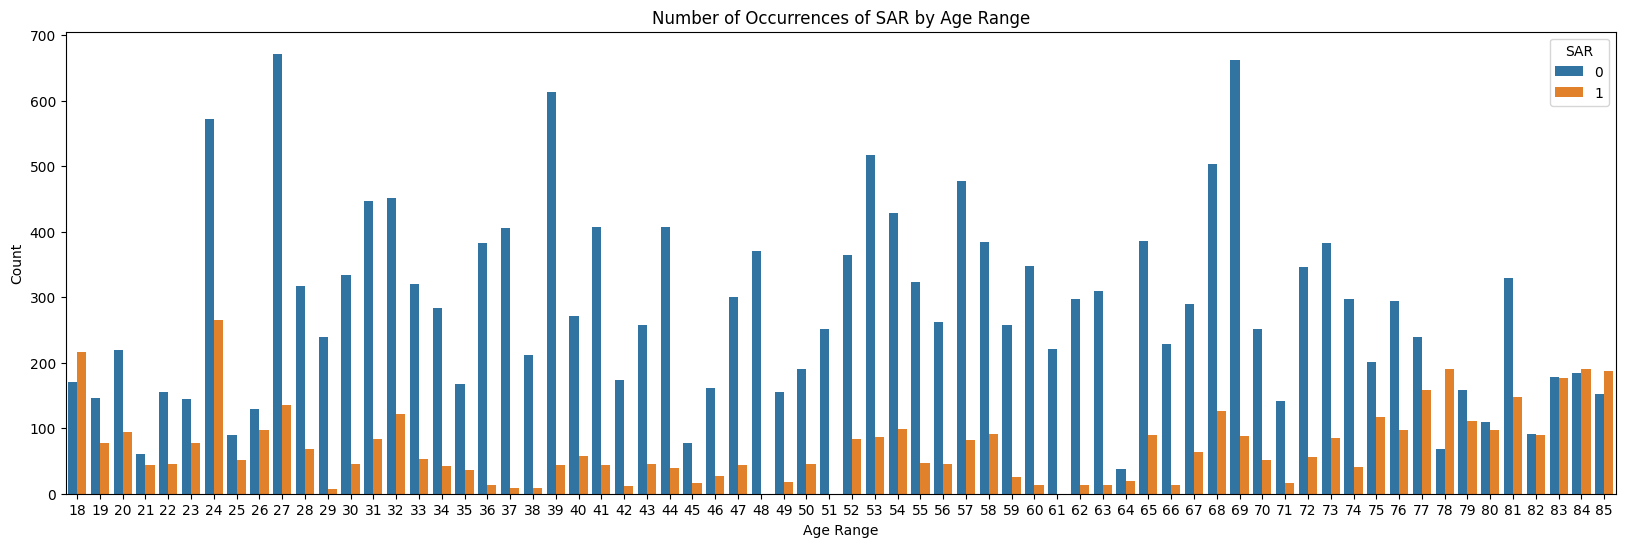

In [ ]:
plt.figure(figsize=(20, 6))
sns.countplot(x='Age', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.show()

In [ ]:
# Calculate SAR count by age group
sar_counts_by_age = trusted_data.groupby(["Age", "SAR"]).size().unstack(fill_value=0)
print(sar_counts_by_age)
# Add a new column for percentage of SAR = 1
sar_counts_by_age["SAR_1_Percentage"] = (sar_counts_by_age[1] / (sar_counts_by_age[0] + sar_counts_by_age[1])) * 100

# Display the result
print(sar_counts_by_age[["SAR_1_Percentage"]])


SAR    0    1
Age          
18   171  216
19   146   77
20   220   95
21    61   44
22   155   45
..   ...  ...
81   329  147
82    91   89
83   179  176
84   184  190
85   153  188

[68 rows x 2 columns]
SAR  SAR_1_Percentage
Age                  
18          55.813953
19          34.529148
20          30.158730
21          41.904762
22          22.500000
..                ...
81          30.882353
82          49.444444
83          49.577465
84          50.802139
85          55.131965

[68 rows x 1 columns]


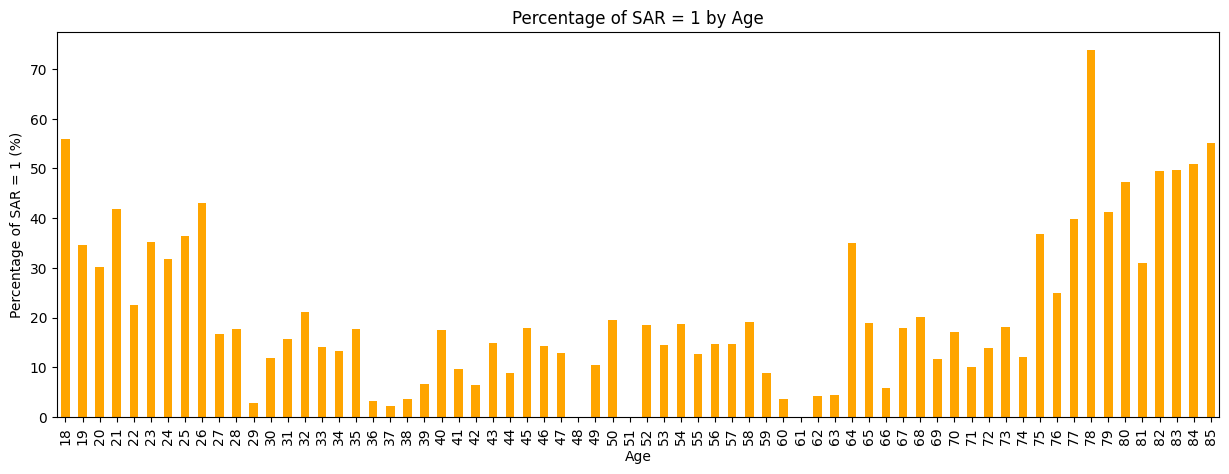

In [ ]:
import matplotlib.pyplot as plt

# Plot the percentage of SAR = 1 by age
sar_counts_by_age["SAR_1_Percentage"].plot(kind="bar", figsize=(15, 5), color="orange")
plt.title("Percentage of SAR = 1 by Age")
plt.xlabel("Age")
plt.ylabel("Percentage of SAR = 1 (%)")
plt.show()


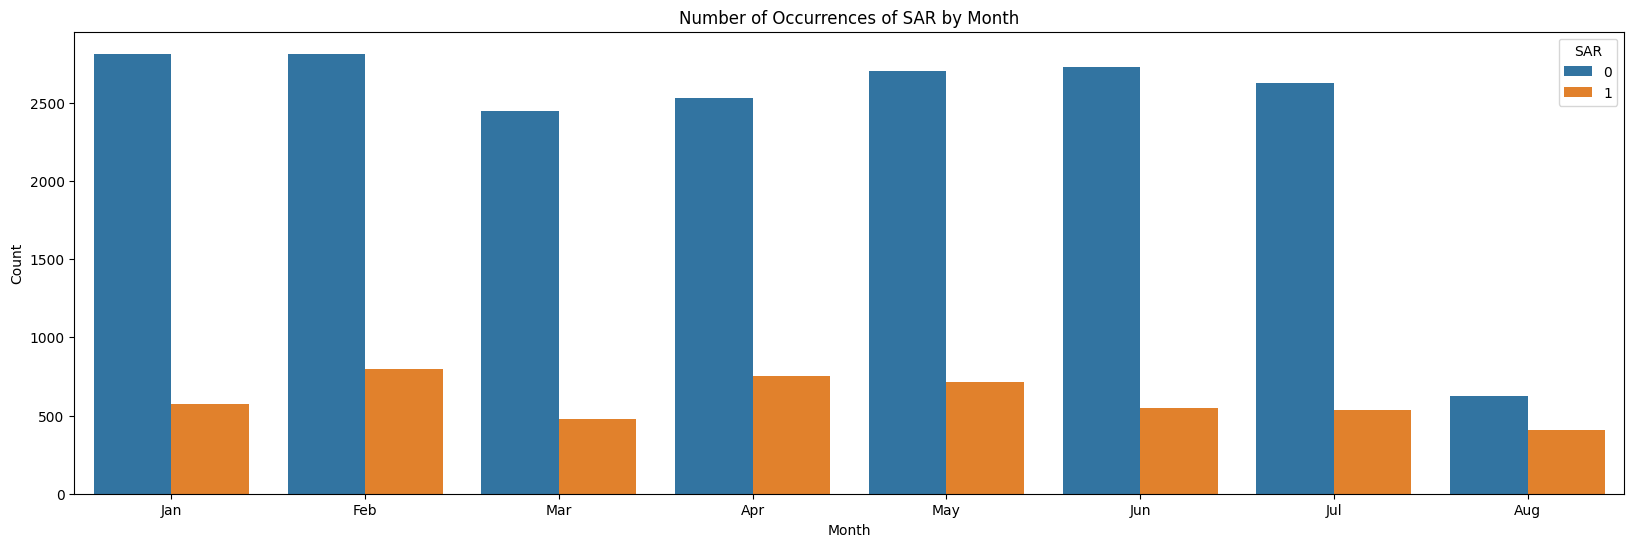

In [ ]:
plt.figure(figsize=(20, 6))
sns.countplot(x='Month', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

In [ ]:
trusted_data = trusted_data.drop(columns=["Month", "Customer_ID", "Customer_ID_Counterparty"])
trusted_data.head()

,Transaction_Value,Transaction_Type,SAR,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits
0,-221.0,Wire,0,59,Female,True,False,True,False
5,5.0,Wire,0,69,Male,True,False,False,False
7,-1373.0,Wire,0,62,Male,False,False,False,False
10,-1992.0,Wire,0,53,Male,True,False,False,True
11,-1055.0,Wire,0,76,Male,True,False,True,True


In [ ]:
# Perform one-hot encoding on the 'Transaction_Type' column
trusted_data = pd.get_dummies(trusted_data, columns=['Transaction_Type'], prefix='Transaction')

# Display the resulting DataFrame
print(trusted_data.head())

    Transaction_Value  SAR  Age     Sex  High_Risk_Country  Vulnerable_Area  \
0              -221.0    0   59  Female               True            False   
5                 5.0    0   69    Male               True            False   
7             -1373.0    0   62    Male              False            False   
10            -1992.0    0   53    Male               True            False   
11            -1055.0    0   76    Male               True            False   

    Intention_International_Payments  Intention_Cash_Deposits  \
0                               True                    False   
5                              False                    False   
7                              False                    False   
10                             False                     True   
11                              True                     True   

    Transaction_Cash  Transaction_International  Transaction_Wire  
0              False                      False              True 

In [ ]:
# Define age bins and labels
bins = [0, 25, 45, 65, 100]  # Specify age ranges
labels = ['young', 'lower_middle', 'upper_middle', 'old']  # Corresponding labels

# Create a new column 'Age_Group' with the categorized data
trusted_data['Age_Group'] = pd.cut(trusted_data['Age'], bins=bins, labels=labels, right=False)

# Display the resulting DataFrame
print(trusted_data[['Age', 'Age_Group']].head())
trusted_data.head()

    Age     Age_Group
0    59  upper_middle
5    69           old
7    62  upper_middle
10   53  upper_middle
11   76           old


,Transaction_Value,SAR,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits,Transaction_Cash,Transaction_International,Transaction_Wire,Age_Group
0,-221.0,0,59,Female,True,False,True,False,False,False,True,upper_middle
5,5.0,0,69,Male,True,False,False,False,False,False,True,old
7,-1373.0,0,62,Male,False,False,False,False,False,False,True,upper_middle
10,-1992.0,0,53,Male,True,False,False,True,False,False,True,upper_middle
11,-1055.0,0,76,Male,True,False,True,True,False,False,True,old


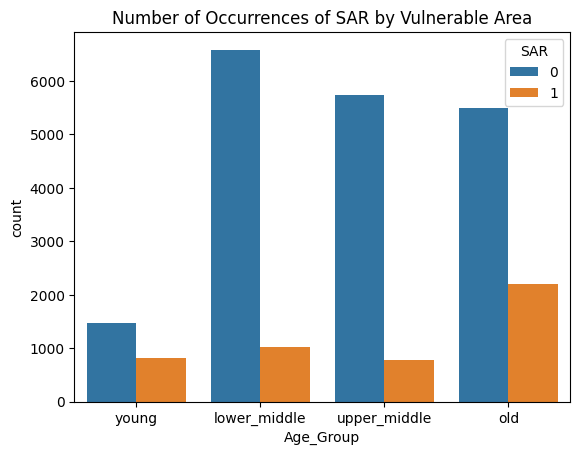

In [ ]:
sns.countplot(x='Age_Group', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Vulnerable Area')
plt.show()

In [ ]:
# Perform one-hot encoding on the 'Transaction_Type' column
trusted_data = pd.get_dummies(trusted_data, columns=['Age_Group'], prefix='Age_Is')

# Display the resulting DataFrame
print(trusted_data.head())

    Transaction_Value  SAR  Age     Sex  High_Risk_Country  Vulnerable_Area  \
0              -221.0    0   59  Female               True            False   
5                 5.0    0   69    Male               True            False   
7             -1373.0    0   62    Male              False            False   
10            -1992.0    0   53    Male               True            False   
11            -1055.0    0   76    Male               True            False   

    Intention_International_Payments  Intention_Cash_Deposits  \
0                               True                    False   
5                              False                    False   
7                              False                    False   
10                             False                     True   
11                              True                     True   

    Transaction_Cash  Transaction_International  Transaction_Wire  \
0              False                      False              True

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

# Encode the target variable
target = LabelEncoder().fit_transform(trusted_data['SAR'])

# Select categorical features for chi-square test
categorical_features = ['Sex', 'High_Risk_Country', 'Vulnerable_Area']

# Perform chi-square test
chi_scores = chi2(trusted_data[categorical_features], target)

# Display chi-square scores and p-values
print("Chi-square scores:", chi_scores[0])
print("P-values:", chi_scores[1])


Chi-square scores: [ 6.14487305  6.59055998 91.45501794]
P-values: [1.31793626e-02 1.02520919e-02 1.14157923e-21]


In [ ]:
# Convert all boolean values in the DataFrame to integers (1 for True, 0 for False)
trusted_data = trusted_data.applymap(lambda x: int(x) if isinstance(x, bool) else x)

# Display the updated DataFrame
print(trusted_data.head())

<ipython-input-18-18099d53cc9d>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  trusted_data = trusted_data.applymap(lambda x: int(x) if isinstance(x, bool) else x)


    Transaction_Value  SAR  Age     Sex  High_Risk_Country  Vulnerable_Area  \
0              -221.0    0   59  Female                  1                0   
5                 5.0    0   69    Male                  1                0   
7             -1373.0    0   62    Male                  0                0   
10            -1992.0    0   53    Male                  1                0   
11            -1055.0    0   76    Male                  1                0   

    Intention_International_Payments  Intention_Cash_Deposits  \
0                                  1                        0   
5                                  0                        0   
7                                  0                        0   
10                                 0                        1   
11                                 1                        1   

    Transaction_Cash  Transaction_International  Transaction_Wire  \
0                  0                          0                 1

In [ ]:
from os import times_result
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'Sex' column
trusted_data['Sex'] = label_encoder.fit_transform(trusted_data['Sex'])

# Display the unique values in the 'Sex' column after encoding
print(trusted_data['Sex'].unique())
trusted_data.head()

[0 1]


,Transaction_Value,SAR,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits,Transaction_Cash,Transaction_International,Transaction_Wire,Age_Is_young,Age_Is_lower_middle,Age_Is_upper_middle,Age_Is_old
0,-221.0,0,59,0,1,0,1,0,0,0,1,0,0,1,0
5,5.0,0,69,1,1,0,0,0,0,0,1,0,0,0,1
7,-1373.0,0,62,1,0,0,0,0,0,0,1,0,0,1,0
10,-1992.0,0,53,1,1,0,0,1,0,0,1,0,0,1,0
11,-1055.0,0,76,1,1,0,1,1,0,0,1,0,0,0,1


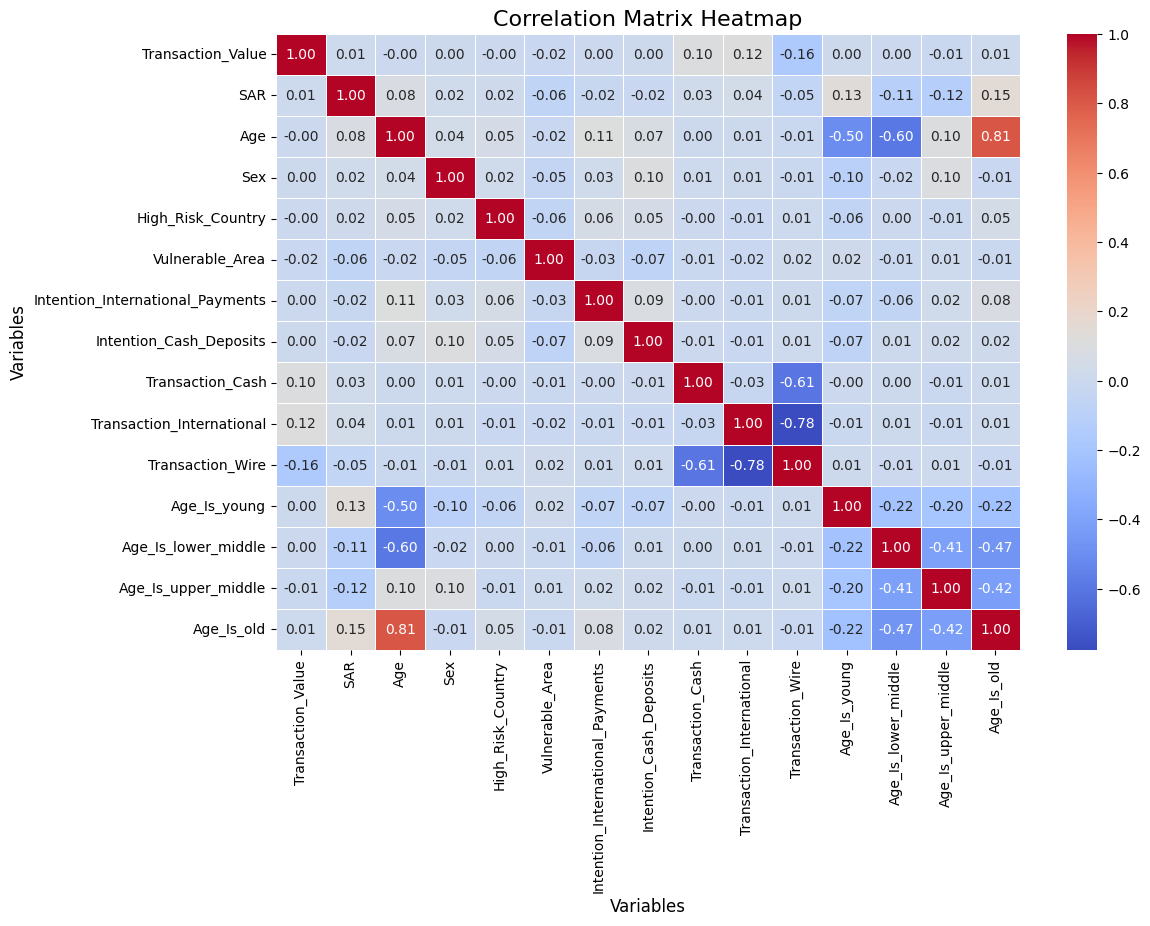

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame with the correlation matrix is named `correlation_df`
plt.figure(figsize=(12, 8))  # Set the figure size
sns.heatmap(trusted_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Add title and labels
plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Variables", fontsize=12)

# Display the heatmap
plt.show()

NameError: name 'categorical_columns' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Define features and target variable
X = trusted_data.drop(columns=['SAR'])  # Features
y = trusted_data['SAR']  # Target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features (SVM is sensitive to scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVM classifier
svm_classifier = SVC(kernel='rbf', probability=True, random_state=42)

# Train the SVM model
svm_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svm_classifier.predict(X_test_scaled)
y_pred_proba = svm_classifier.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("Classification Report:")
print(classification_rep)


Accuracy: 0.80
ROC-AUC Score: 0.68
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      3857
           1       0.59      0.05      0.09       960

    accuracy                           0.80      4817
   macro avg       0.70      0.52      0.49      4817
weighted avg       0.76      0.80      0.73      4817



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Define features and target variable
X = trusted_data.drop(columns=['SAR'])  # Features
y = trusted_data['SAR']  # Target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("Classification Report:")
print(classification_rep)


Accuracy: 0.80
ROC-AUC Score: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      3857
           1       0.49      0.44      0.47       960

    accuracy                           0.80      4817
   macro avg       0.68      0.66      0.67      4817
weighted avg       0.79      0.80      0.79      4817



In [ ]:
# Merge transactions with labels
df_merged = pd.merge(df_transactions, df_labels, on=["Customer_ID", "Month"], how="inner")

# Exclude salary transactions
df_merged = df_merged[df_merged["Transaction_Type"] == "Salary"]
df_merged.head()

,Customer_ID,Customer_ID_Counterparty,Transaction_Value,Transaction_Type,Month,SAR
25,59,NaN,4924,Salary,Jan,0
61,930,NaN,2762,Salary,Jan,0
87,634,NaN,9948,Salary,Jan,0
120,3,NaN,6293,Salary,Jan,0
144,743,NaN,2951,Salary,Jan,0


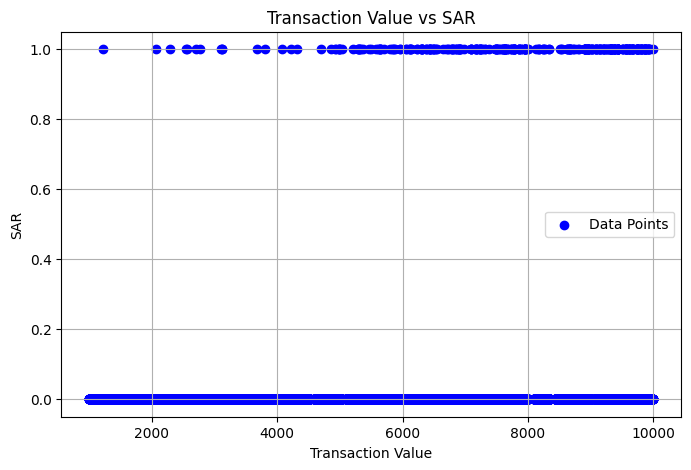

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df_merged["Transaction_Value"], df_merged["SAR"], color='blue', label="Data Points")
plt.title("Transaction Value vs SAR")
plt.xlabel("Transaction Value")
plt.ylabel("SAR")
plt.legend()
plt.grid(True)
plt.show()